In [5]:
from pathlib import Path

# enable ipympl widgets for zoom
# %matplotlib widget
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
#from matplotlib.ticker import FixedLocator
from matplotlib.ticker import NullLocator, AutoMinorLocator, MultipleLocator
import pandas as pd
import pint_pandas  # needed for initialization

In [6]:
#sns.set_theme()
#sns.set_theme(style="white")
#sns.set_theme(style="whitegrid")
#sns.set_theme(style="ticks")
sns.set_theme(
    style="ticks",
    context="paper",
    rc={
        "axes.linewidth": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out"
    }
)

In [7]:
def import_dataset(filename: Path):
    df = pd.read_csv(filename, header=[0, 1])

    names = df.columns.get_level_values(0)
    units = df.columns.get_level_values(1)

    df.columns = names  # flatten
    if 'timestamp' in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], format="ISO8601")
    for col, unit in zip(names, units):  # apply units
        if unit != "No Unit":
            df[col] = df[col].astype(f"pint[{unit}]")

    return df

In [70]:
image_folder = Path.cwd() / "resources/images"
image_folder.mkdir(parents=True, exist_ok=True)
experiment_folder = Path("../data_processing")
resources_folder = experiment_folder / "resources"
df = import_dataset(resources_folder / "tp_tp_radxax4_gzip_pigz_bzip2_lbzip2_bzip3_xz_lz4_lzop_zstd_tp_raspi5_gzip_pigz_bzip2_lbzip2_bzip3_xz_lz4_lzop_zstd.csv")
df["average_throughput"] = df["average_throughput"].pint.to("MiB/s")

In [71]:
# Convert Pint quantities to magnitudes if necessary
plot_df = df.pint.dequantify()
plot_df.columns = plot_df.columns.get_level_values(0)
plot_df = plot_df.drop(columns=["num_runs", "average_real"])

In [94]:
def plot_faceted(df, host, mode):
    df = df[df["host"] == host]
    df = df[df["mode"] == mode]
    ncols = 5
    g = sns.relplot(
        data=df,
        x="strength",
        y="average_throughput",
        hue="dataset",
        style="threading",
        col="tool",
        col_wrap=ncols,
        kind="line",
        marker="o",
        height=2.0,
        aspect=0.85,
        facet_kws={"sharey": False},
    )
    for ax in g.axes.flat:
        #ax.minorticks_on()
        ax.yaxis.minorticks_on()
        #ax.yaxis.set_minor_locator(MultipleLocator(0.2))
        #ax.xaxis.set_minor_locator(NullLocator())

    for ax in g.axes.flat:        
        #ax.yaxis.grid(True, linestyle="-", linewidth=0.5, alpha=0.95)
        ax.grid(axis="y", which="major", linestyle="-", alpha=0.9)
        ax.grid(axis="y", which="minor", linestyle=":", alpha=0.75)
        ax.xaxis.grid(False)
    
    for ax in g.axes.flat:
        ax.set_xlabel(ax.get_xlabel(), fontsize=7)
        ax.set_ylabel(ax.get_ylabel(), fontsize=8)
        ax.tick_params(axis="x", labelsize=7)
        ax.tick_params(axis="y", labelsize=8)        
    
    # Remove the default legend (outside the figure)
    if g._legend is not None:
        g._legend.remove()

    ax = g.axes[0]
    handles, labels = ax.get_legend_handles_labels()
    
    legend = g.figure.legend(
        handles,
        labels,
        title="Legend",
        loc="center",
        bbox_to_anchor=(0.82, 0.25),  # adjust as needed
        frameon=True,
    )
    
    for text in legend.texts:
        if text.get_text() == "dataset":
            text.set_text("Dataset")
        elif text.get_text() == "threading":
            text.set_text("Threading")
    
    # Optionally hide the axes if it is unused
    #ax.set_axis_off()

    g.set_axis_labels("strength", "throughput MiB/s")
    g.fig.subplots_adjust(wspace=0.3, hspace=0.25)
    
    file_name = image_folder / f"throughput_{host}_{mode}.pdf"
    #print("generate: %s" % file_name)
    g.fig.savefig(file_name, bbox_inches="tight")
    
    plt.show()

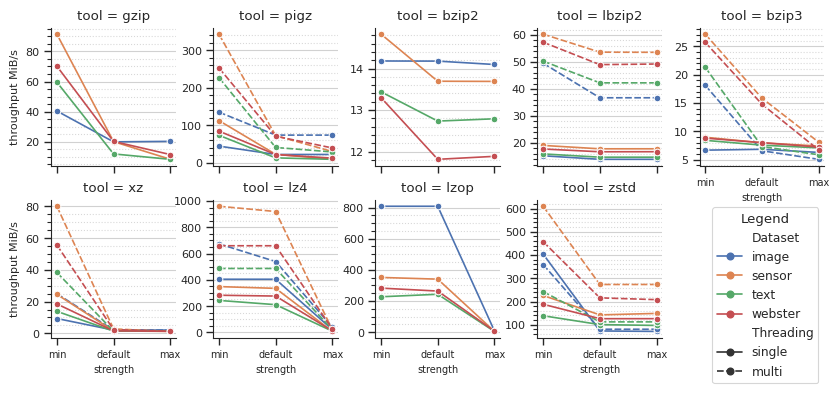

In [95]:
plot_faceted(plot_df, host="radxax4", mode="compress")